In [25]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from matplotlib import rcParams
rcParams['font.family'] = 'Arial'
rcParams['pdf.fonttype'] = 42  # Use TrueType fonts
rcParams['axes.linewidth'] = 0.5
rcParams['xtick.major.width'] = 0.5
rcParams['ytick.major.width'] = 0.5
rcParams['savefig.dpi'] = 300  # Ensure a high resolution

In [27]:
dataset_name = 'juvenile'
config_file = '../dataset_configs/juvenile_dataset_t7.json'
# dataset_name = 'juvenile_dfovf'
# dataset_name = 'juvenile_noise_std0p2'
# dataset_name = 'juvenile_noise_std0p5'
# config_file = f'../../{dataset_name}_dataset/notebooks/{dataset_name}_dataset.json'

# dataset_name = 'adult'
# config_file = '../dataset_configs/adult_dataset.json'

window_name = 'time_window_3s'
# window_name = 'time_window_5s'
# window_name = 'time_window_7s'

from analysis_config import juvenile_window_name_to_frames, adult_window_name_to_frames
if dataset_name.startswith('juvenile'):
    frame_window = juvenile_window_name_to_frames[window_name]
    do_reorder_cs = True
    odor_orders = ['cs_plus', 'cs_minus', 'aa3', 'TDCA', 'TCA', 'GCA']
    vsnames = ['aa_vs_aa', 'aa_vs_ba', 'ba_vs_ba']
elif dataset_name.startswith('adult'):
    frame_window = adult_window_name_to_frames[window_name]
    do_reorder_cs = False
    odor_orders = None
    vsnames = ['learned_vs_learned', 'learned_vs_novel', 'novel_vs_novel']


print(window_name, frame_window)
metric = 'cosine'
# metric = 'pattern_correlation'

from matplotlib.colors import Normalize, PowerNorm
if metric == 'cosine':
    cmap = 'jet_r'
    clim = [0, 0.55]
    if dataset_name == 'juvenile_dfovf':
        clim = [0, 0.7]
    color_norm = PowerNorm(gamma=1.7)
    if dataset_name == 'adult':
        color_norm = None
else:
    cmap = 'jet'
    clim = [0, 1]
    color_norm = None

import os
fig_dir = f'../figures/{dataset_name}/{window_name}/{metric}/'
os.makedirs(fig_dir, exist_ok=True)


time_window_3s [38, 63]


2021-07-15-DpOBEM-N2_Dp None
2021-07-15-DpOBEM-N2_Dp None
2021-07-16-DpOBEM-N3_Dp None
2021-12-10-DpOBEM-N4_Dp None
2021-12-31-DpOBEM-N7_Dp None
2022-02-13-DpOBEM-N10_Dp None
2022-02-20-DpOBEM-N11_Dp None
2021-02-05-DpOBEM-JH9_Dp None
2021-03-18-DpOBEM-JH10_Dp None
2021-03-19-DpOBEM-JH10_Dp None
2021-04-02-DpOBEM-JH11_Dp None
2021-04-03-DpOBEM-JH11_Dp None
2021-05-01-DpOBEM-JH13_Dp None
2021-05-22-DpOBEM-JH14_Dp None
2021-09-15-DpOBEM-JH20_Dp None
2021-09-17-DpOBEM-JH20_Dp None
2021-09-18-DpOBEM-JH20_Dp None
2021-07-30-DpOBEM-JH17_Dp None
2021-07-31-DpOBEM-JH17_Dp None
2021-09-02-DpOBEM-JH18_Dp None
2021-09-03-DpOBEM-JH18_Dp None
2021-09-04-DpOBEM-JH18_Dp None
2021-09-29-DpOBEM-JH21_Dp None
2021-10-01-DpOBEM-JH21_Dp None
2021-10-02-DpOBEM-JH21_Dp None
2021-10-14-DpOBEM-JH22_Dp None
2021-11-10-DpOBEM-JH23_Dp None
2021-11-11-DpOBEM-JH23_Dp None
2021-11-14-DpOBEM-JH23_Dp None
2021-11-24-DpOBEM-JH24_Dp None
2021-11-27-DpOBEM-JH24_Dp None
2021-11-26-DpOBEM-JH24_Dp None
ylabel_ vfontsize: 7


C:\Users\hubob\Projects\Dp_manifold_rest\catrace\catrace\visualize.py:624: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  mean_points = datadf.groupby(


F:\FMI_tachyon_hubo\Dp_manifold\juvenile_dataset\data\spike_prob_long\per_odor_aligned\index_formatted_firing_rate\cosine\window_38to63\cross_trial_similarity.pkl


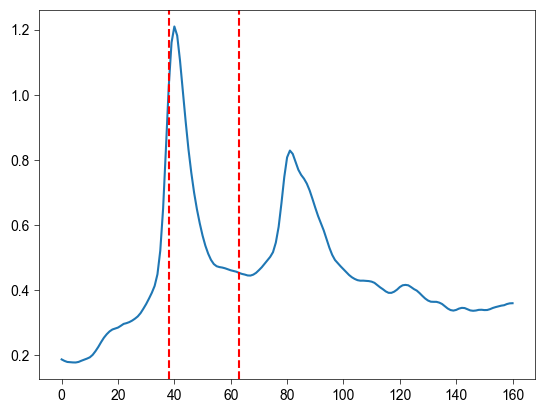

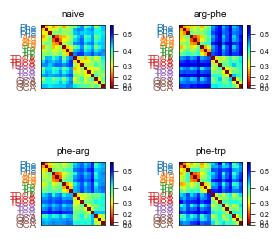

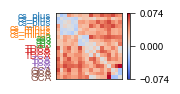

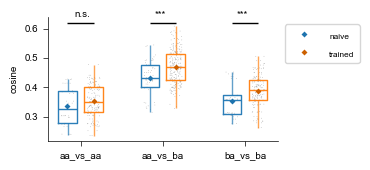

In [28]:
from catrace.run.run_pattern_similarity import run_pattern_similarity, RunPatternSimilarityParams, PlotPatternSimilarityParams
from catrace.visualize import PlotPerCondMatParams, PlotBoxplotMultiOdorCondParams
from matplotlib.colors import Normalize, PowerNorm
plot_params = PlotPatternSimilarityParams(
    per_cond = PlotPerCondMatParams(
        row_height=1.45,#1.35,
        col_width=1.45,#1.35,
        title_fontsize=7,
        ylabel_fontsize=7,
        ylabel_colors = None,
        ylabels = None,
        cmap=cmap,
        clim=clim,
        color_norm=color_norm,
        cbar_interval=0.1,
        colorbar_fontsize=5,
    ),
    mean_delta = dict(
        figsize=(1.9, 1.9),
        colorbar_fontsize = 7,
        ylabel_fontsize = 7,
    ),
    vs_measure = PlotBoxplotMultiOdorCondParams(
        figsize=(3.8, 1.8),
        label_fontsize=7,
        show_ns=True,
        mean_marker_size=1,
        pvalue_marker_xoffset=0.04,
        box_linewidth=1,
        strip_alpha=0.8,
        strip_size=0.5,
        pvalue_bar_linewidth=1,
    )
)

params = RunPatternSimilarityParams(
    config_file = config_file,
    assembly_name = '',
    time_window = frame_window,
    metric = metric,
    overwrite_computation = False,
    do_plot_per_fish = False,
    do_plot_per_condition = True,
    do_save_cross_trial = True,
    do_reorder_cs = do_reorder_cs,
    odor_orders = odor_orders,
    plot_params = plot_params,
    vsnames = vsnames,
    manifold_level = 'odor',
)

if params.assembly_name == '':
    assembly_label = 'all_neurons'
else:
    assembly_label = params.assembly_name

window_tag = f'window_{params.time_window[0]}_{params.time_window[1]}'
sim_dir, output_figs, test_results, cross_trial_path, simdf_list, exp_list = run_pattern_similarity(params, return_data=True)
print(cross_trial_path)

In [29]:
from catrace.for_paper import save_figure_for_paper

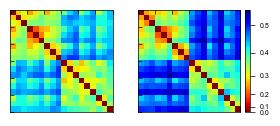

In [30]:
import copy
from matplotlib.ticker import MultipleLocator

def adjust_fig_per_cond(output_figs):
    fig_per_cond_copy = copy.deepcopy(output_figs['fig_per_cond'])
    ax = fig_per_cond_copy.get_axes()
    # Remove title for ax[0] and ax[1]
    ax[0].set_title('')
    ax[1].set_title('')
    # Delete y ticks
    # ax[0].set_yticks([])
    # ax[1].set_yticks([])
    # Delete y tick labels
    ax[0].set_yticklabels([])
    ax[1].set_yticklabels([])
    # put y ticks with interval of 3 using multiple locator
    ax[0].yaxis.set_major_locator(MultipleLocator(3))
    ax[1].yaxis.set_major_locator(MultipleLocator(3))
    # Get current y-ticks and adjust them to start at -0.5
    y_ticks_0 = ax[0].get_yticks()[1:]
    y_ticks_1 = ax[1].get_yticks()[1:]
    
    ax[0].set_yticks(y_ticks_0 - 0.5)
    ax[1].set_yticks(y_ticks_1 - 0.5)
    # Show y ticks
    ax[0].tick_params(axis='y', length=3, direction='in')
    ax[1].tick_params(axis='y', length=3, direction='in')

    # Do the same for x ticks
    ax[0].xaxis.set_major_locator(MultipleLocator(3))
    ax[1].xaxis.set_major_locator(MultipleLocator(3))
    x_ticks_0 = ax[0].get_xticks()[1:]
    x_ticks_1 = ax[1].get_xticks()[1:]
    ax[0].set_xticks(x_ticks_0 - 0.5)
    ax[1].set_xticks(x_ticks_1 - 0.5)
    ax[0].tick_params(axis='x', length=3, direction='in')
    ax[1].tick_params(axis='x', length=3, direction='in')
    ax[0].set_xticklabels([])
    ax[1].set_xticklabels([])
    # Put x ticks on top of the axes
    ax[0].xaxis.set_ticks_position('top')
    ax[1].xaxis.set_ticks_position('top')
    # # Delete colorbar on the first axes
    fig = fig_per_cond_copy
    # Keep arg-phe
    fig.delaxes(fig.axes[2])
    fig.delaxes(fig.axes[5])
    fig.delaxes(fig.axes[2])
    fig.delaxes(fig.axes[4])
    fig.delaxes(fig.axes[2])
    fig_per_cond_copy.tight_layout()
    return fig_per_cond_copy


fig_per_cond_copy = adjust_fig_per_cond(output_figs)
save_figure_for_paper(fig_per_cond_copy, f'{dataset_name}_{params.metric}_per_cond', fig_dir)
fig_per_cond_copy

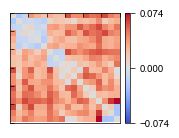

In [31]:
def adjust_ticks(ax):
    """
    Adjust the ticks of a single axes object.

    Parameters:
    - ax (matplotlib.axes.Axes): The axes object to be modified.
    """
    # Delete y tick labels
    ax.set_yticklabels([])
    
    # Set y ticks with an interval of 3 using MultipleLocator
    ax.yaxis.set_major_locator(MultipleLocator(3))
    
    # Get current y-ticks and adjust them to start at -0.5
    y_ticks = ax.get_yticks()[1:]
    ax.set_yticks(y_ticks - 0.5)
    
    # Show y ticks
    ax.tick_params(axis='y', length=3, direction='in')
    
    # Do the same for x ticks
    ax.xaxis.set_major_locator(MultipleLocator(3))
    x_ticks = ax.get_xticks()[1:]
    ax.set_xticks(x_ticks - 0.5)
    ax.tick_params(axis='x', length=3, direction='in')
    ax.xaxis.set_ticks_position('top')
    
    # Delete x tick labels
    ax.set_xticklabels([])


def adjust_fig_delta(output_figs):
    fig_delta_copy = copy.deepcopy(output_figs['fig_delta'])
    ax = fig_delta_copy.get_axes()
    adjust_ticks(ax[0])
    fig_delta_copy.tight_layout()
    return fig_delta_copy

fig_delta_copy = adjust_fig_delta(output_figs)
save_figure_for_paper(fig_delta_copy, f'{dataset_name}_{params.metric}_{window_tag}_mean_delta', fig_dir)
fig_delta_copy

C:\Users\hubob\AppData\Local\Temp\ipykernel_26904\1688101096.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_xlabels)


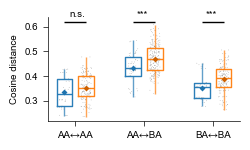

In [32]:
fig = output_figs['fig_multi_vs']
ax = fig.get_axes()[0]
# ax.set_ylim((0, 0.68))
ylabel = ax.get_ylabel()
if ylabel=='cosine':
    new_ylabel = 'Cosine distance'
else:
    new_ylabel = ylabel
ax.set_ylabel(new_ylabel)

if dataset_name.startswith('juvenile'):
    vslabel_mapping = {'aa_vs_aa': 'AA↔AA',
                    'aa_vs_ba': 'AA↔BA',
                    'ba_bs_aa': 'BA↔AA',
                    'ba_vs_ba': 'BA↔BA'}
elif dataset_name.startswith('adult'):
    vslabel_mapping = {'learned_vs_learned': 'L↔L',
                    'learned_vs_novel': 'L↔N',
                    'novel_vs_novel': 'N↔N'}
else:
    # Identity mapping
    vslabel_mapping = {key: key for key in vsnames}
xlabels = ax.get_xticklabels()
new_xlabels = [vslabel_mapping[label.get_text()] for label in xlabels]
ax.set_xticklabels(new_xlabels)
if ax.get_legend() is not None:
    ax.get_legend().remove()
# Change figure size
#fig.set_size_inches(2.8, 1.8)
fig.set_size_inches(2.6, 1.6)
fig.tight_layout()
save_figure_for_paper(output_figs['fig_multi_vs'], f'{dataset_name}_{params.metric}_{window_tag}_multi_vs', fig_dir)
output_figs['fig_multi_vs']

In [33]:
from catrace.stats import format_test_results_multi_odor_two_cond
sentence = format_test_results_multi_odor_two_cond(test_results)
sentence = sentence.replace('aa_vs_aa', 'AvsA').replace('aa_vs_ba', 'AvsB').replace('ba_vs_aa', 'BvsA').replace('ba_vs_ba', 'BvsB')
print(sentence)

For AvsA, Comparing naive (mean = 0.34 ± 0.0639, n = 36) vs trained (mean = 0.35 ± 0.0531, n = 150): Mann–Whitney U test, U = 2232.00, P = 0.107. For AvsB, Comparing naive (mean = 0.43 ± 0.0579, n = 54) vs trained (mean = 0.47 ± 0.0571, n = 225): Mann–Whitney U test, U = 4100.00, P = 0.0002. For BvsB, Comparing naive (mean = 0.35 ± 0.0552, n = 36) vs trained (mean = 0.39 ± 0.0538, n = 150): Mann–Whitney U test, U = 1716.00, P = 0.0007.


In [ ]:
simdf_list
exp_list

# Concatenate simdf_list into a single DataFrame
import pandas as pd
all_simdf = pd.concat(simdf_list, keys=exp_list, names=['fish_id', 'condition'])
all_simdf

odor                                                 Phe                      \
trial                                                  0         1         2   
fish_id                   condition odor trial                                 
2021-07-15-DpOBEM-N2_Dp   naive     Phe  0      0.000000  0.244332  0.326319   
                                         1      0.244332  0.000000  0.314239   
                                         2      0.326319  0.314239  0.000000   
                                    Arg  0      0.304510  0.330896  0.361765   
                                         1      0.344135  0.324395  0.343035   
...                                                  ...       ...       ...   
2021-11-26-DpOBEM-JH24_Dp phe-trp   TCA  1      0.400313  0.361889  0.441129   
                                         2      0.501243  0.456953  0.448477   
                                    GCA  0      0.384294  0.360724  0.436923   
                                         1      0.383202  0.340656  0.421377   
                                         2      0.511774  0.458101  0.471709   

odor                                                 Arg                      \
trial                                                  0         1         2   
fish_id                   condition odor trial                                 
2021-07-15-DpOBEM-N2_Dp   naive     Phe  0      0.304510  0.344135  0.400809   
                                         1      0.330896  0.324395  0.378057   
                                         2      0.361765  0.343035  0.332479   
                                    Arg  0      0.000000  0.153412  0.204588   
                                         1      0.153412  0.000000  0.162360   
...                                                  ...       ...       ...   
2021-11-26-DpOBEM-JH24_Dp phe-trp   TCA  1      0.383996  0.388440  0.423904   
                                         2      0.449361  0.459084  0.493142   
                                    GCA  0      0.357515  0.367742  0.410815   
                                         1      0.359925  0.366192  0.395565   
                                         2      0.474821  0.459499  0.495230   

odor                                                 Trp                      \
trial                                                  0         1         2   
fish_id                   condition odor trial                                 
2021-07-15-DpOBEM-N2_Dp   naive     Phe  0      0.317035  0.342596  0.392279   
                                         1      0.354374  0.324436  0.360518   
                                         2      0.377217  0.349435  0.363660   
                                    Arg  0      0.321842  0.372509  0.397692   
                                         1      0.370141  0.372394  0.400526   
...                                                  ...       ...       ...   
2021-11-26-DpOBEM-JH24_Dp phe-trp   TCA  1      0.381291  0.353715  0.445101   
                                         2      0.444533  0.419252  0.475957   
                                    GCA  0      0.320343  0.310936  0.400904   
                                         1      0.331091  0.296277  0.396186   
                                         2      0.442903  0.398479  0.450654   

odor                                                TDCA                      \
trial                                                  0         1         2   
fish_id                   condition odor trial                                 
2021-07-15-DpOBEM-N2_Dp   naive     Phe  0      0.502993  0.561587  0.575442   
                                         1      0.523568  0.581181  0.610352   
                                         2      0.488110  0.518730  0.536695   
                                    Arg  0      0.500754  0.512817  0.566192   
                                         1      0.530502  0.544830  0.611756 

In [40]:
all_simdf

# Save all_simdf to a CSV file
# Save result data to CSV
figure_data_dir = os.path.join('../../publish_dataset/Hu_Temiz_et_al_dataset', 'figure_data')
os.makedirs(figure_data_dir, exist_ok=True)
save_dir = os.path.join(figure_data_dir, 'figure02')
os.makedirs(save_dir, exist_ok=True)
all_simdf.to_csv(os.path.join(save_dir, f'figure02abc_cosine_distances.csv'))

save_dir = os.path.join(figure_data_dir, 'extended_figure02')
os.makedirs(save_dir, exist_ok=True)
all_simdf.to_csv(os.path.join(save_dir, f'extended_figure02b_cosine_distances.csv'))
